Notebook for determining appropriate scenario weighting.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import post_event_gm_gnn as pg

In [2]:
mpl.rcdefaults()  # Resets Matplotlib settings

# Disable FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
# Config
# obs_data_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v4.1/Tables/ground_motion_im_table_rotd50_flat.csv")
obs_data_ffp = Path("/Users/claudy/dev/work/data/gm_datasets/nz_gmdb/v4.3_final/custom/mod_ground_motion_im_table_rotd50_flat.csv")

**NZGMDB File Path:** `{python} str(nzgmdb_ffp)`  
**NZGMDB version:** `{python} str(nzgmdb_ffp.parent.parent.name)` 

In [4]:
# Scenario selection criteria
max_dist=30
closest_max_dist=10
max_n_obs_sites=10
min_n_obs_sites=2

mag_min_weight = 0.0
mag_max_weight = 5.0
min_mag = 5.0
max_mag = 7.0

doc_min_weight = 0.0
doc_max_weight = 0.0
doc_linear_start = 1.0
doc_linear_end = 6.0 

**Maximum Distance:** `{python} str(max_dist)`  
**Closest Maximum Distance:** `{python} str(closest_max_dist)`  
**Maximum Number of Observation Sites:** `{python} str(max_n_obs_sites)`  
**Minimum Number of Observation Sites:** `{python} str(min_n_obs_sites)`

In [5]:
# Load observed data
obs_data = pg.data.load_obs_nzgmdb(obs_data_ffp)

events, all_sites = obs_data.events, obs_data.sites
event_sites = obs_data.event_sites
print(f"Number of records: {obs_data.n_records}")
print(f"Number of events: {len(events)}")

Number of records: 55013
Number of events: 2361


In [6]:
# Get the set of valid site-interests per event
print("Getting valid sites of interest")
int_sites, valid_event_int_sites, _ = pg.ml.data.get_valid_site_ints_Lee2024(
    event_sites, obs_data.record_df.drop(columns=obs_data.ims)
)
events = np.intersect1d(events, np.asarray(list(valid_event_int_sites.keys())))

Getting valid sites of interest
Valid GM records: 47867/55013


In [7]:
# Distance matrix
dist_matrix = pg.utils.calculate_distance_matrix(all_sites, obs_data.site_df)

In [8]:
# Loth & Baker spatial correlations
corr_data = pg.LBSiteCorrelationData.from_dist_matrix(dist_matrix, pg.constants.PSA_KEYS)

In [9]:
# Compute available scenarios
obs_sites = all_sites

site_combs, event_sites = pg.ml.data.compute_site_combinations(
    event_sites,
    valid_event_int_sites,
    events,
    dist_matrix,
    obs_sites,
    int_sites,
    max_dist,
    closest_max_dist,
    max_n_obs_sites,
    min_n_obs_sites
)

In [10]:
# Create scenario dataframe
scenario_df = pg.ml.utils.create_scenario_df(site_combs, event_sites, obs_data, dist_matrix=dist_matrix, lb_corr_data=corr_data)
print(f"Number of scenarios: {len(scenario_df)}")

Number of scenarios: 25127


## Magnitude

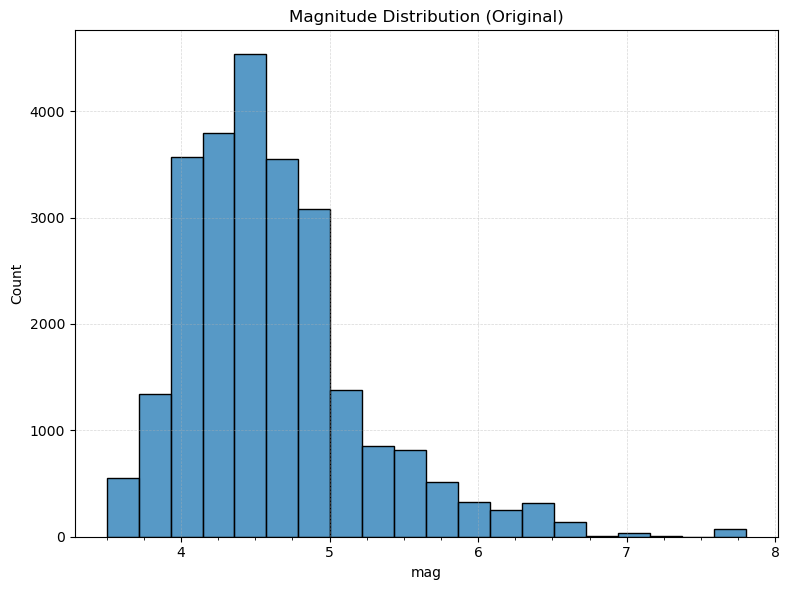

In [11]:
# Plot magnitude distribution
fig, ax  = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["mag"], bins=20, ax=ax)
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax.set_title("Magnitude Distribution (Original)")
fig.tight_layout()

In [12]:
weight_func = pg.ml.gnn_gm.get_mag_weight_func(mag_min_weight, mag_max_weight, min_mag, max_mag)

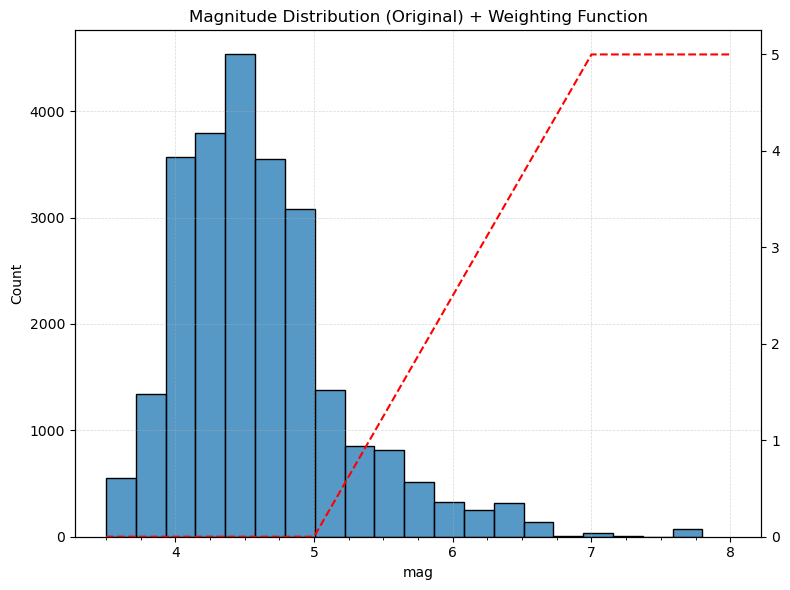

In [13]:
# Plot magnitude distribution
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["mag"], bins=20, ax=ax)
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

# Weighting
mag_values = np.linspace(scenario_df.mag.min(), 8, 100)
weights = np.asarray([weight_func(cur_mag) for cur_mag in mag_values])
ax_weight = ax.twinx()
ax_weight.plot(mag_values, weights, color="red", linestyle="--")
ax_weight.set_ylim(0.0, None)

ax.set_title("Magnitude Distribution (Original) + Weighting Function")

fig.tight_layout()

In [14]:
scenario_df["mag_weight"] = [1 + weight_func(cur_mag) for cur_mag in scenario_df["mag"].values]

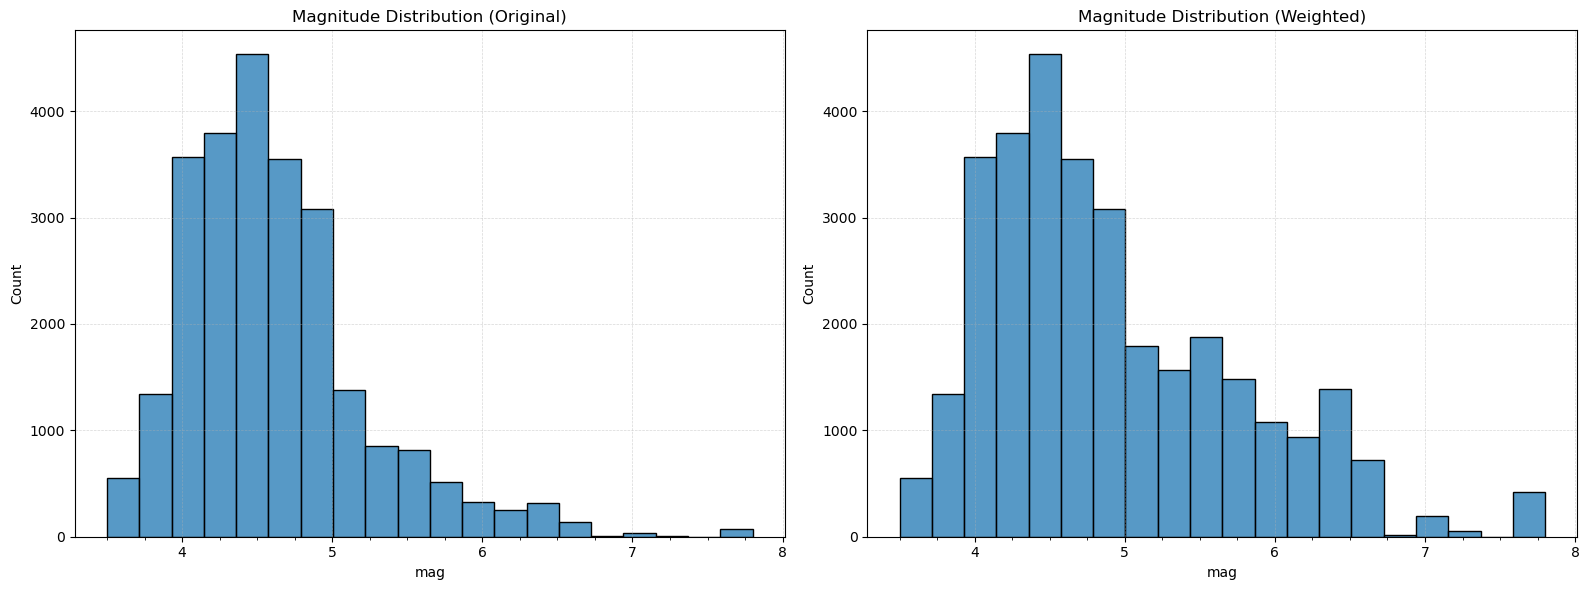

In [15]:
# Plot magnitude distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax1.set_title("Magnitude Distribution (Original)")


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax2, weights="mag_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

ax2.set_title("Magnitude Distribution (Weighted)")

fig.tight_layout()

## $R_{Rup}$

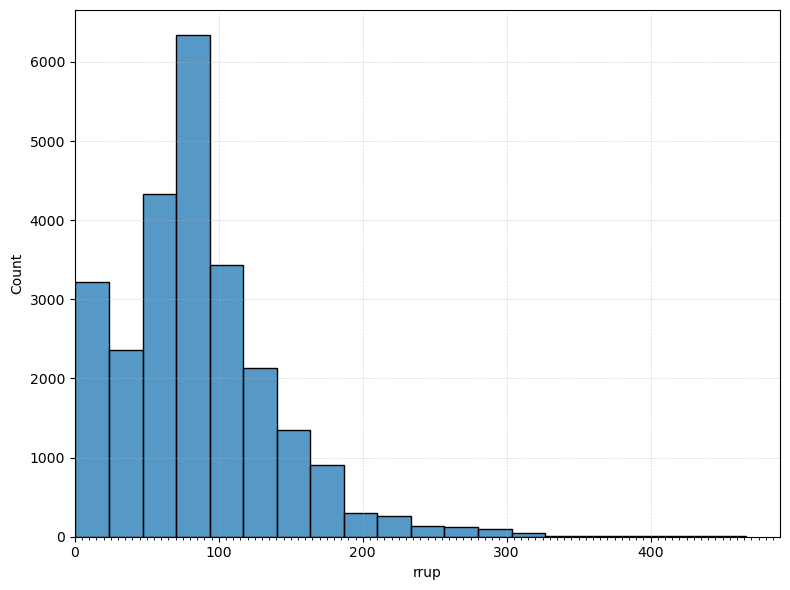

In [16]:
# Plot distance distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["rrup"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(5))
ax_hist.set_xlim(0.0)
fig.tight_layout()

Don't think $R_{Rup}$ needs to be weighted.

## Degree of Constraint

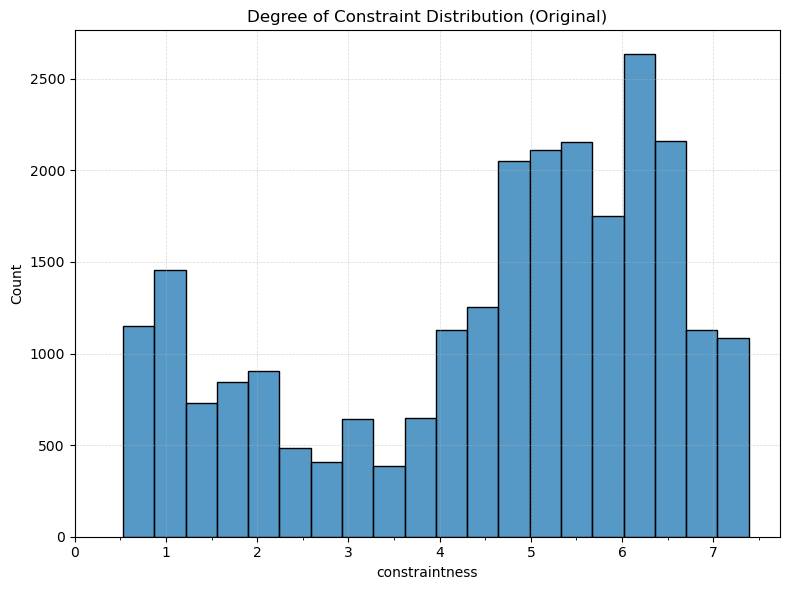

In [17]:
# Plot degree of constraint distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["constraintness"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax_hist.set_xlim(0.0)

ax_hist.set_title("Degree of Constraint Distribution (Original)")

fig.tight_layout()

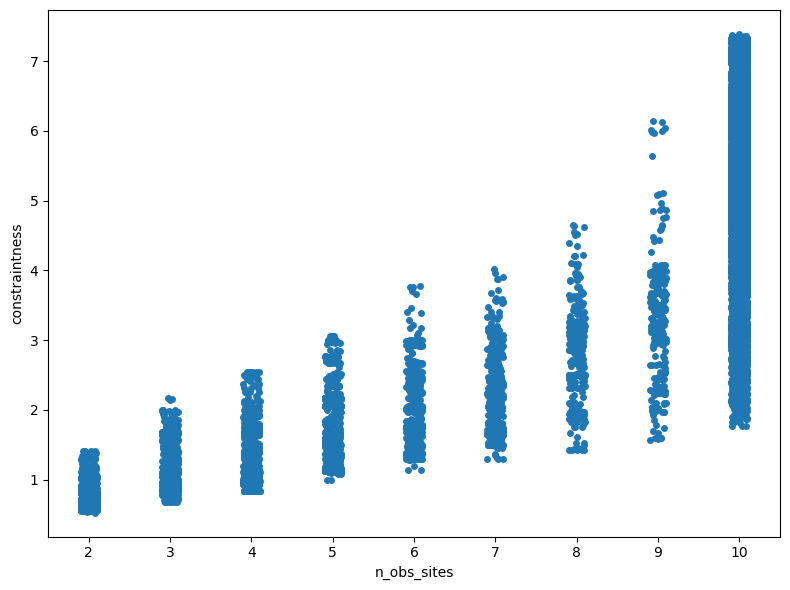

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.stripplot(data=scenario_df, x="n_obs_sites", y="constraintness", ax=ax)
fig.tight_layout()

In [19]:
# def doc_weight_fn(doc: np.ndarray[float], max_weight: float = 2, min_weight: float = 1, linear_doc_start: float = 1, linear_doc_end: float = 6):
#     weights = np.ones_like(doc)
#
#     grad = (max_weight - min_weight) / (linear_doc_end - linear_doc_start)
#     bias = max_weight - (grad * linear_doc_end)
#
#     weights = np.where(doc > 1, doc * grad + bias, weights)
#     return weights

In [20]:
doc_weight_fn = pg.ml.gnn_gm.get_doc_weight_func(doc_min_weight, doc_max_weight, doc_linear_start, doc_linear_end)

In [21]:
# scenario_df["doc_weight"] = doc_weight_fn(scenario_df["n_obs_sites"])
scenario_df["doc_weight"] = [1 + doc_weight_fn(cur_doc) for cur_doc in scenario_df["constraintness"].values]

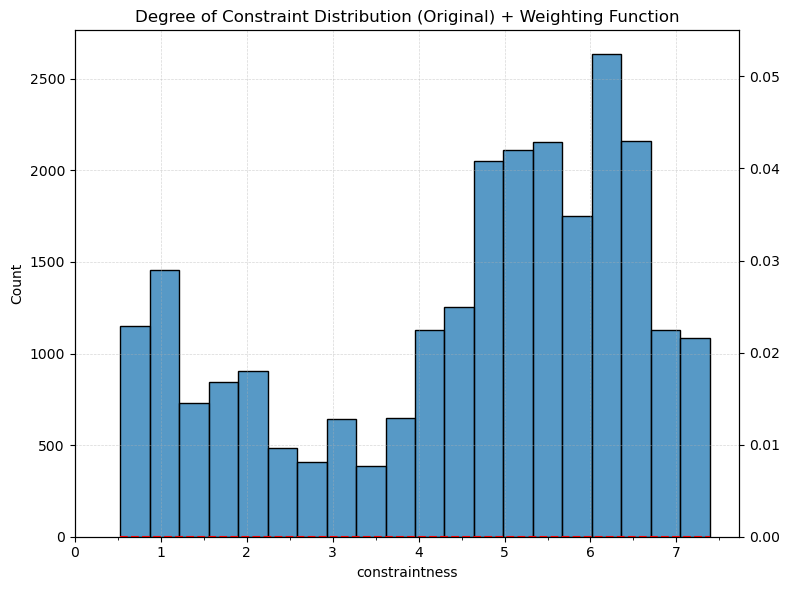

In [22]:
# Plot degree of constraint distribution
fig, ax_hist = plt.subplots(1, 1, figsize=(8, 6))
sns.histplot(scenario_df["constraintness"], bins=20, ax=ax_hist)
ax_hist.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax_hist.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax_hist.set_xlim(0.0)

# Weighting
doc_values = np.linspace(scenario_df.constraintness.min(), scenario_df.constraintness.max(), 100)
weights = [doc_weight_fn(cur_doc) for cur_doc in doc_values]
# weights = doc_weight_fn(doc_values)

ax_weight = ax_hist.twinx()
ax_weight.plot(doc_values, weights, color="red", linestyle="--")
ax_weight.set_ylim(0.0, None)

ax_hist.set_title("Degree of Constraint Distribution (Original) + Weighting Function")

fig.tight_layout()

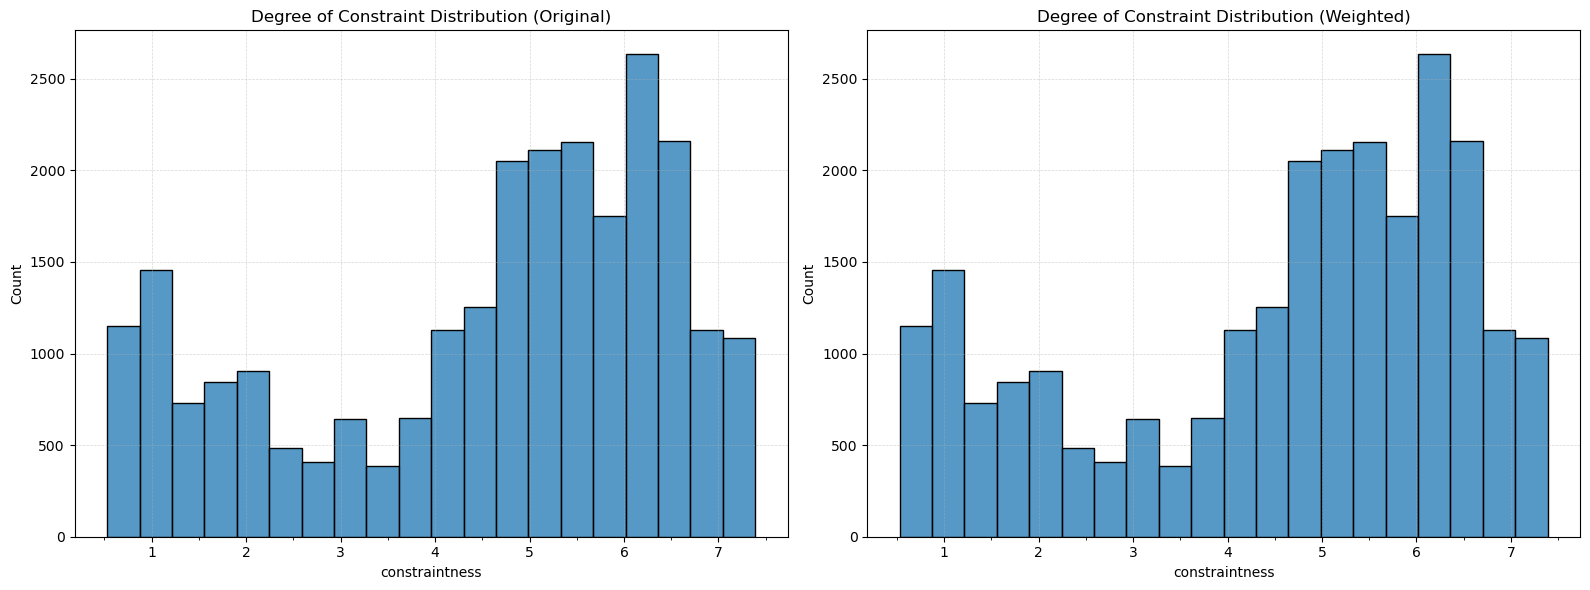

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax1.set_title("Degree of Constraint Distribution (Original)")

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax2, weights="doc_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax2.set_title("Degree of Constraint Distribution (Weighted)")

fig.tight_layout()


## Combined Weighting

In [24]:
# The -1 is due to the double counting of the initial weight of 1
scenario_df["combined_weight"] = scenario_df["mag_weight"] + scenario_df["doc_weight"] - 1

In [25]:
# Plot combined weighting
# sns.displot(data=scenario_df, x="mag", y="constraintness", weights="combined_weight", kind="hist", bins=(10, 25))

In [26]:
# sns.displot(data=scenario_df, x="mag", y="constraintness", kind="hist", bins=(10, 25))

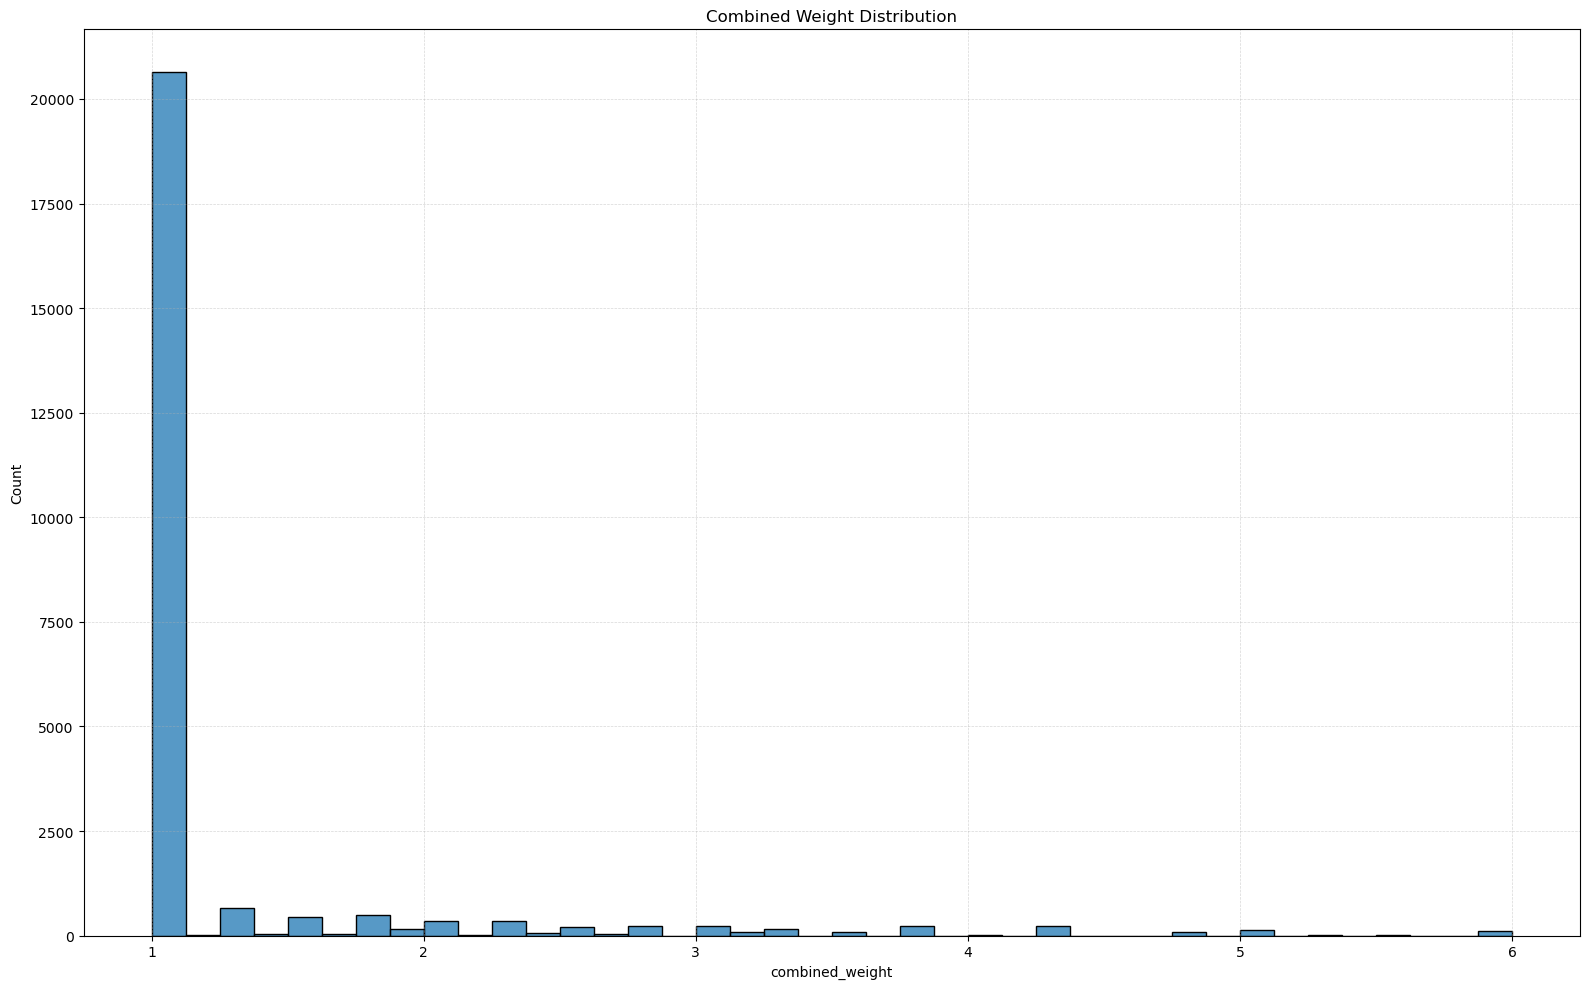

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))

sns.histplot(data=scenario_df, x="combined_weight", bins=40, ax=ax)
# sns.scatterplot(data=scenario_df, x="mag", y="mag_weight", ax=ax)
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

ax.set_title("Combined Weight Distribution")

fig.tight_layout()

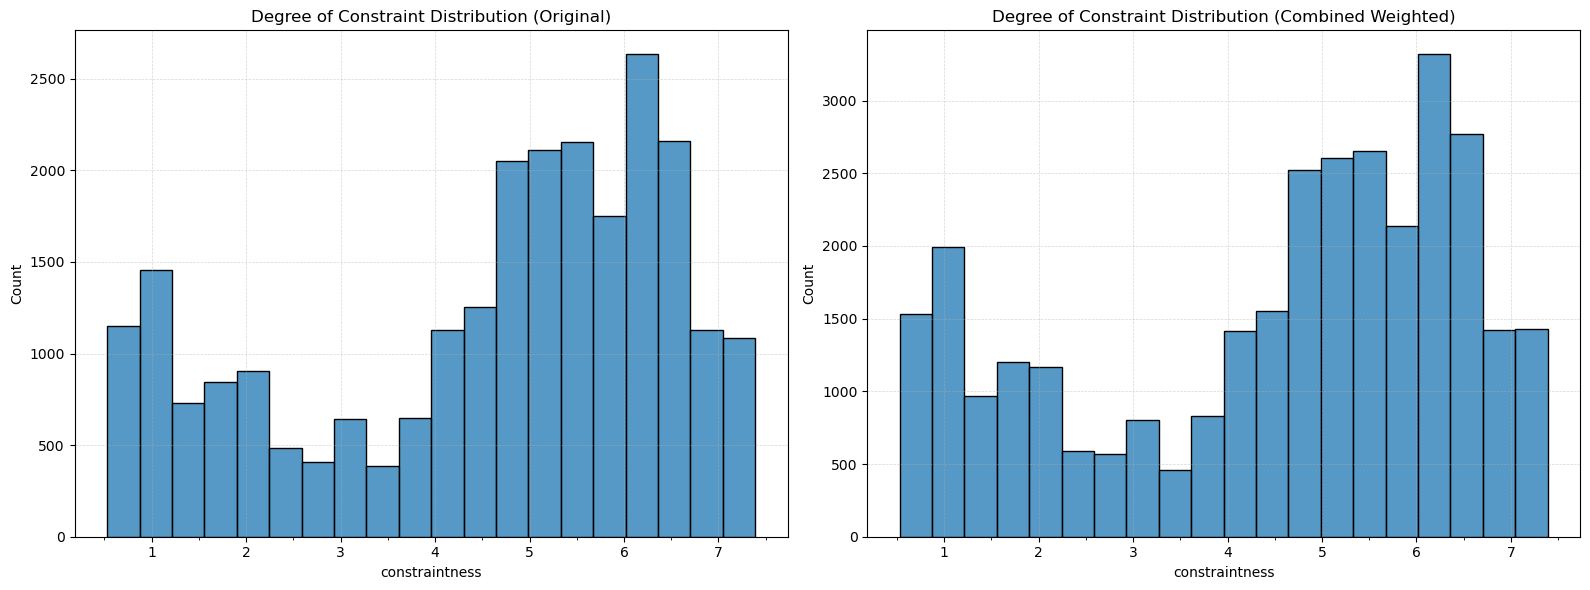

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax1.set_title("Degree of Constraint Distribution (Original)")

sns.histplot(data=scenario_df, x="constraintness", bins=20, ax=ax2, weights="combined_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax2.set_title("Degree of Constraint Distribution (Combined Weighted)")

fig.tight_layout()


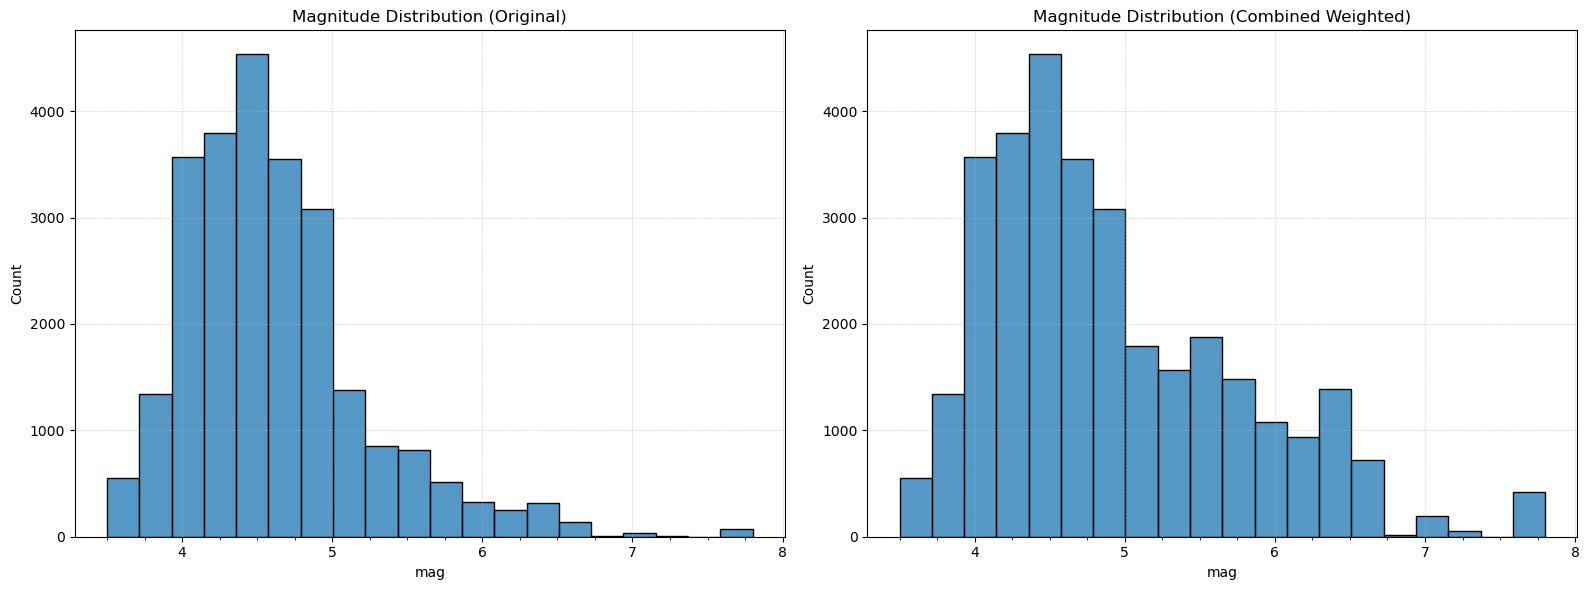

In [29]:
# Plot magnitude distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax1)
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
ax1.set_title("Magnitude Distribution (Original)")


sns.histplot(data=scenario_df, x="mag", bins=20, ax=ax2, weights="combined_weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.xaxis.set_minor_locator(plt.MultipleLocator(0.25))

ax2.set_title("Magnitude Distribution (Combined Weighted)")

fig.tight_layout()